# 09 — LLM-as-judge (Qwen2.5-7B-Instruct) over the 91 conditions

## Big picture

Pipeline position:
`... → 07_kg_rerank → 08_llm_eval → **09_llm_judge**`

**Goal**: for each `(query_id, condition)` produced by notebook 08,
decide with a strong-but-cheap judge LLM whether the response generated
by Llama-2 contains at least one of the **gold answers** for that query.
Output: one boolean per row.

Why an LLM judge instead of substring match: NQ answers come as a list
of accepted variants (`["10 miles", "ten miles"]`, `["Paul Telfer",
"Telfer"]`) and the generator's response is often verbose or paraphrased
("The song is performed by..." / "10 MILES (from Document [4])"). Plain
substring match collapses on case, plurals, punctuation, paraphrases, and
preambles. An LLM judge handles all of these natively.

**Why Qwen2.5-7B-Instruct (and not Llama-2 again)**: judge MUST be a
different family from the generator to avoid pet-grades-itself bias, AND
it must be at least as instruction-tuned as the generator — a base-level
model would noise the verdicts. Qwen2.5-7B-Instruct (Apache 2.0, no
license gating) is strong and free. Pinned to Qwen2.5 (not Qwen3)
because our installed transformers (4.48) does not yet ship the
`qwen3` architecture class.

**Scale**: 91 conditions × 1000 queries = **91000 binary judgments**.

## I/O

**Inputs** (`data/NQ_answer/`):
- `queries_curated.jsonl`                      — gold answers per query
- `llm_eval/llm_responses_{condition}.jsonl`   — 91 files from 08

**Outputs** (`data/NQ_answer/llm_eval/`):
- `judgments_{condition}.jsonl`                — 91 files, schema:
  `{query_id, condition, response, gold_answers, judge_raw, verdict_bool}`
- `judgments_summary.parquet`                  — aggregated TRUE counts +
  accuracy + McNemar p-value per (condition vs retrieval)

**Model**: `Qwen/Qwen2.5-7B-Instruct` (HuggingFace, Apache 2.0, no gating).

## 1 · Setup

In [1]:
import json
import os
import re
import time
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    GenerationConfig,
)

In [2]:
# Determinism setup. Must run BEFORE any CUDA initialization so that
# CUBLAS_WORKSPACE_CONFIG is picked up by the CUDA context at startup.
# Same rationale as notebook 08 — see comments there for details.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"determinism: seed={SEED}, "
      f"deterministic_algorithms=True (warn_only), cudnn=deterministic")

determinism: seed=42, deterministic_algorithms=True (warn_only), cudnn=deterministic


In [3]:
# Walk-up to repo root via pyproject.toml — same pattern as other notebooks.
def find_repo_root() -> Path:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").is_file():
            return p
    raise RuntimeError("Could not find repo root (pyproject.toml)")


REPO_ROOT = find_repo_root()
NQ_DIR = REPO_ROOT / "data" / "NQ_answer"
LLM_EVAL_DIR = NQ_DIR / "llm_eval"

QUERIES_PATH = NQ_DIR / "queries_curated.jsonl"
JUDGMENTS_SUMMARY_PATH = LLM_EVAL_DIR / "judgments_summary.parquet"

print(f"REPO_ROOT: {REPO_ROOT}")
for p in [QUERIES_PATH, LLM_EVAL_DIR]:
    flag = "OK" if p.exists() else "MISSING"
    print(f"  [{flag}] {p.relative_to(REPO_ROOT)}")

REPO_ROOT: C:\Users\Utente\Documents\PycharmProjects\dl-RAG-denseAndKG
  [OK] data\NQ_answer\queries_curated.jsonl
  [OK] data\NQ_answer\llm_eval


In [4]:
# Load HF token from .hf_token (gitignored) and expose it via env var so that
# AutoTokenizer / AutoModelForCausalLM in section 5 can authenticate
# (Qwen2.5 is Apache 2.0 with no gating, but downloading still benefits
# from a logged-in token for rate-limit reasons).
HF_TOKEN_PATH = REPO_ROOT / ".hf_token"
if HF_TOKEN_PATH.is_file():
    os.environ["HF_TOKEN"] = HF_TOKEN_PATH.read_text(encoding="utf-8").strip()
    print(f"HF_TOKEN loaded from {HF_TOKEN_PATH.name} (len={len(os.environ['HF_TOKEN'])})")
elif "HF_TOKEN" in os.environ:
    print(f"HF_TOKEN already in env (len={len(os.environ['HF_TOKEN'])})")
else:
    print("WARNING: no HF_TOKEN found (download may work anyway since Qwen2.5 is open).")

HF_TOKEN loaded from .hf_token (len=37)


## 2 · Configuration

In [5]:
# Qwen naming note: Qwen2.5 series keeps the explicit "-Instruct" suffix
# for the chat-tuned variant (vs the bare "Qwen/Qwen2.5-7B" base model).
JUDGE_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# Inference knobs
BATCH_SIZE = 8                # Qwen2.5-7B at 4-bit ~5 GB → can afford larger batches than Llama-2-7B
JUDGE_MAX_NEW_TOKENS = 10     # binary YES/NO needs <5 tokens; 10 = safety buffer
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Conditions: mirror exactly what 08 produced (retrieval + 5 alphas × 18 cells)
CELL_DIST_VARIANTS: list[int] = [1, 2, 3]
THR_VARIANTS: list[tuple[int, str]] = [
    (500, "thr500"),
    (1000, "thr1k"),
    (2000, "thr2k"),
    (5000, "thr5k"),
    (10000, "thr10k"),
    (0, "thrinf"),
]
ALPHAS_TO_TEST = [0.1, 0.3, 0.5, 0.7, 0.9]
CONDITIONS: list[str] = ["retrieval"]
for _dist in CELL_DIST_VARIANTS:
    for _thr_value, _thr_label in THR_VARIANTS:
        for _alpha in ALPHAS_TO_TEST:
            CONDITIONS.append(f"alpha_{int(round(_alpha * 10))}_dist{_dist}_{_thr_label}")
print(f"conditions: {len(CONDITIONS)}  "
      f"(retrieval + {len(CELL_DIST_VARIANTS)}×{len(THR_VARIANTS)}×{len(ALPHAS_TO_TEST)})")
print(f"first 6: {CONDITIONS[:6]}")
print(f"last 6:  {CONDITIONS[-6:]}")

# Sanity print
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("WARNING: no GPU available, will be very slow on CPU")

conditions: 91  (retrieval + 3×6×5)
first 6: ['retrieval', 'alpha_1_dist1_thr500', 'alpha_3_dist1_thr500', 'alpha_5_dist1_thr500', 'alpha_7_dist1_thr500', 'alpha_9_dist1_thr500']
last 6:  ['alpha_9_dist3_thr10k', 'alpha_1_dist3_thrinf', 'alpha_3_dist3_thrinf', 'alpha_5_dist3_thrinf', 'alpha_7_dist3_thrinf', 'alpha_9_dist3_thrinf']
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM total: 15.9 GB


## 3 · Load inputs

### 3.1 · Queries with gold answers

In [6]:
queries: list[dict] = [json.loads(line) for line in QUERIES_PATH.open(encoding="utf-8")]
print(f"queries loaded: {len(queries):,}")
# Sanity: every query must have a non-empty 'answers' field (gold).
n_no_gold = sum(1 for q in queries if not q.get("answers"))
print(f"  queries with NO gold answers: {n_no_gold}")

queries loaded: 1,000
  queries with NO gold answers: 0


In [7]:
# Lookup query_id (str, positional 0..999) → list of gold answer strings
gold_by_qid: dict[str, list[str]] = {
    str(i): (q.get("answers") or []) for i, q in enumerate(queries)
}
print(f"gold lookup built: {len(gold_by_qid)} queries, "
      f"avg {sum(len(v) for v in gold_by_qid.values()) / len(gold_by_qid):.2f} variants/query")

gold lookup built: 1000 queries, avg 1.01 variants/query


### 3.2 · Responses from notebook 08 (all 91 conditions)

In [8]:
# Load each llm_responses_{condition}.jsonl into one long DataFrame.
# Schema after load: (query_id, condition, question, response, passage_ids).
rows: list[dict] = []
for condition in CONDITIONS:
    path = LLM_EVAL_DIR / f"llm_responses_{condition}.jsonl"
    if not path.exists():
        print(f"  [MISSING] {path.name}")
        continue
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            d = json.loads(line)
            d["condition"] = condition
            rows.append(d)
    print(f"  [OK] {path.name}: loaded")

df_resp = pd.DataFrame(rows)
print(f"\ntotal response rows: {len(df_resp):,}  "
      f"(expected: {len(CONDITIONS)} × 1000 = {len(CONDITIONS) * 1000})")

  [OK] llm_responses_retrieval.jsonl: loaded
  [OK] llm_responses_alpha_1_dist1_thr500.jsonl: loaded
  [OK] llm_responses_alpha_3_dist1_thr500.jsonl: loaded
  [OK] llm_responses_alpha_5_dist1_thr500.jsonl: loaded
  [OK] llm_responses_alpha_7_dist1_thr500.jsonl: loaded
  [OK] llm_responses_alpha_9_dist1_thr500.jsonl: loaded
  [OK] llm_responses_alpha_1_dist1_thr1k.jsonl: loaded
  [OK] llm_responses_alpha_3_dist1_thr1k.jsonl: loaded
  [OK] llm_responses_alpha_5_dist1_thr1k.jsonl: loaded
  [OK] llm_responses_alpha_7_dist1_thr1k.jsonl: loaded
  [OK] llm_responses_alpha_9_dist1_thr1k.jsonl: loaded
  [OK] llm_responses_alpha_1_dist1_thr2k.jsonl: loaded
  [OK] llm_responses_alpha_3_dist1_thr2k.jsonl: loaded
  [OK] llm_responses_alpha_5_dist1_thr2k.jsonl: loaded
  [OK] llm_responses_alpha_7_dist1_thr2k.jsonl: loaded
  [OK] llm_responses_alpha_9_dist1_thr2k.jsonl: loaded
  [OK] llm_responses_alpha_1_dist1_thr5k.jsonl: loaded
  [OK] llm_responses_alpha_3_dist1_thr5k.jsonl: loaded
  [OK] llm_resp

In [9]:
df_resp.head(1)

,query_id,question,passage_ids,response,condition
0,0,this artist was signed in 1952 by atlantic and...,"[41894427, 41894428, 1398885, 1398886, 1398872]",Ray Charles,retrieval


In [10]:
# Attach gold answers for each row. Rows with response=None (overflow skips
# from 08) get dropped — there's nothing to judge.
df_resp["gold_answers"] = df_resp["query_id"].map(gold_by_qid)
n_null_resp = df_resp["response"].isna().sum()
print(f"rows with response=null (overflow from 08): {n_null_resp:,}")
df_resp = df_resp.dropna(subset=["response"]).reset_index(drop=True)
print(f"rows kept for judging: {len(df_resp):,}")

rows with response=null (overflow from 08): 0
rows kept for judging: 91,000


## 4 · Build judge prompts (Qwen2.5 chat template, structured)

Two messages: a strict `system` defining the task, and a `user`
containing the (question, gold list, response) triple. Qwen2.5 chat
template wraps with `<|im_start|>system / <|im_start|>user /
<|im_start|>assistant` and closes turns with `<|im_end|>`. No thinking
mode to disable (that's a Qwen3-only feature).

In [11]:
JUDGE_SYSTEM_PROMPT = (
    "You are a strict judge. Given a question, a list of acceptable answers, "
    "and a model response, decide whether the response contains at least one "
    "of the acceptable answers (verbatim or as a clear paraphrase). "
    "Reply with exactly YES or NO, nothing else."
)


def build_judge_user_message(question: str, gold_answers: list[str], response: str) -> str:
    """User-turn message for one judgment: triple (Q, gold list, response)."""
    gold_json = json.dumps(gold_answers, ensure_ascii=False)
    return (
        f"Question: {question}\n"
        f"Acceptable answers: {gold_json}\n"
        f"Response: {response}\n\n"
        f"Does the response contain at least one of the acceptable answers? "
        f"Reply YES or NO."
    )


# Demo: show one user message + how it looks chat-templated (after tokenizer loads)
_demo_row = df_resp.iloc[0]
_demo_user = build_judge_user_message(
    _demo_row["question"], _demo_row["gold_answers"], _demo_row["response"]
)
print("=== example judge user message ===")
print(_demo_user)

=== example judge user message ===
Question: this artist was signed in 1952 by atlantic and brought a string of hits
Acceptable answers: ["Ray Charles"]
Response: Ray Charles

Does the response contain at least one of the acceptable answers? Reply YES or NO.


## 5 · Init Qwen2.5-7B (4-bit NF4 via bitsandbytes)

In [12]:
print(f"Loading tokenizer for {JUDGE_MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_NAME)

# Qwen uses <|endoftext|> as eos and has a pad_token of its own usually; if
# missing, alias to eos for batching. padding_side="left" mandatory for
# causal LM batched generation (same reason as in 08).
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
print(f"tokenizer loaded. pad_token={tokenizer.pad_token!r}, "
      f"padding_side={tokenizer.padding_side}, eos_token_id={tokenizer.eos_token_id}")

Loading tokenizer for Qwen/Qwen2.5-7B-Instruct...
tokenizer loaded. pad_token='<|endoftext|>', padding_side=left, eos_token_id=151645


In [13]:
# 4-bit NF4 quantization — same config as 08 (compute_dtype=bfloat16,
# double_quant on). On the RTX 5070 Ti (16 GB), Qwen2.5-7B in 4-bit fits
# in ~5 GB → plenty of headroom for larger batches.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading model {JUDGE_MODEL_NAME} in 4-bit NF4 on {DEVICE}...")
t0 = time.perf_counter()
model = AutoModelForCausalLM.from_pretrained(
    JUDGE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()
print(f"model loaded in {time.perf_counter() - t0:.1f}s")
print(f"model dtype: {model.dtype}")
if torch.cuda.is_available():
    used_gb = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM used: {used_gb:.2f} GB")

Loading model Qwen/Qwen2.5-7B-Instruct in 4-bit NF4 on cuda...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

model loaded in 13.1s
model dtype: torch.float16
VRAM used: 5.22 GB


In [14]:
# Generation config: deterministic short answer. eos_token_id is the
# native Qwen eos (typically <|im_end|>); we don't need a newline stop
# because the model is instruction-tuned and will close the turn cleanly.
gen_config = GenerationConfig(
    max_new_tokens=JUDGE_MAX_NEW_TOKENS,
    do_sample=False,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
)
print(f"generation config: max_new_tokens={JUDGE_MAX_NEW_TOKENS}, greedy")

generation config: max_new_tokens=10, greedy


### 5.1 · Sanity: 1 prompt, 1 generation

In [15]:
_demo_messages = [
    {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
    {"role": "user", "content": _demo_user},
]
_demo_prompt_text = tokenizer.apply_chat_template(
    _demo_messages,
    tokenize=False,
    add_generation_prompt=True,
)
print("=== example chat-templated judge prompt (first 800 chars) ===")
print(_demo_prompt_text[:800])

=== example chat-templated judge prompt (first 800 chars) ===
<|im_start|>system
You are a strict judge. Given a question, a list of acceptable answers, and a model response, decide whether the response contains at least one of the acceptable answers (verbatim or as a clear paraphrase). Reply with exactly YES or NO, nothing else.<|im_end|>
<|im_start|>user
Question: this artist was signed in 1952 by atlantic and brought a string of hits
Acceptable answers: ["Ray Charles"]
Response: Ray Charles

Does the response contain at least one of the acceptable answers? Reply YES or NO.<|im_end|>
<|im_start|>assistant



In [16]:
_demo_inputs = tokenizer(_demo_prompt_text, return_tensors="pt").to(DEVICE)
print(f"prompt tokens: {_demo_inputs.input_ids.shape[1]}")

t0 = time.perf_counter()
with torch.no_grad():
    _demo_output = model.generate(**_demo_inputs, generation_config=gen_config)
elapsed = time.perf_counter() - t0

_demo_input_len = _demo_inputs.input_ids.shape[1]
_demo_judge_raw = tokenizer.decode(
    _demo_output[0][_demo_input_len:], skip_special_tokens=True
).strip()
print(f"\ngeneration: {elapsed:.1f}s")
print(f"question: {_demo_row['question']}")
print(f"gold:     {_demo_row['gold_answers']}")
print(f"response: {_demo_row['response']!r}")
print(f"judge:    {_demo_judge_raw!r}")

prompt tokens: 117

generation: 1.3s
question: this artist was signed in 1952 by atlantic and brought a string of hits
gold:     ['Ray Charles']
response: 'Ray Charles'
judge:    'YES'


## 6 · Batched judgment + per-condition save (resumable)

In [17]:
def chunked(iterable: list, n: int) -> Iterable[list]:
    """Yield successive n-sized chunks from list."""
    for i in range(0, len(iterable), n):
        yield iterable[i : i + n]


def process_condition_judge(
    condition: str,
    df_resp_cond: pd.DataFrame,
    out_path: Path,
    batch_size: int = BATCH_SIZE,
) -> None:
    """Judge all responses for ONE condition, append to out_path JSONL.

    Idempotent: existing query_ids in out_path are skipped (resume after crash).
    Output row schema: {query_id, condition, response, gold_answers,
                        judge_raw, verdict_bool}.
    """
    done_qids: set[str] = set()
    if out_path.exists():
        with out_path.open("r", encoding="utf-8") as f:
            for line in f:
                done_qids.add(json.loads(line)["query_id"])
        print(f"  [{condition}] resume: {len(done_qids):,} already judged, skipping")

    todo = df_resp_cond[~df_resp_cond["query_id"].isin(done_qids)].to_dict("records")
    if not todo:
        print(f"  [{condition}] all done")
        return

    print(f"  [{condition}] judging {len(todo):,} rows in batches of {batch_size}")
    t_cond_start = time.perf_counter()

    with out_path.open("a", encoding="utf-8") as fout:
        for batch_idx, batch in enumerate(chunked(todo, batch_size)):
            # Build chat-templated prompts (one per response)
            prompts = []
            for r in batch:
                user_msg = build_judge_user_message(
                    r["question"], r["gold_answers"], r["response"]
                )
                messages = [
                    {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
                    {"role": "user", "content": user_msg},
                ]
                prompt_text = tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True,
                )
                prompts.append(prompt_text)

            inputs = tokenizer(
                prompts,
                return_tensors="pt",
                padding=True,
                truncation=False,
            ).to(DEVICE)

            with torch.no_grad():
                outputs = model.generate(**inputs, generation_config=gen_config)

            input_len = inputs.input_ids.shape[1]
            for i, r in enumerate(batch):
                response_tokens = outputs[i][input_len:]
                judge_raw = tokenizer.decode(response_tokens, skip_special_tokens=True).strip()
                verdict_bool = parse_yes_no(judge_raw)
                fout.write(json.dumps({
                    "query_id": r["query_id"],
                    "condition": condition,
                    "response": r["response"],
                    "gold_answers": r["gold_answers"],
                    "judge_raw": judge_raw,
                    "verdict_bool": verdict_bool,
                }, ensure_ascii=False) + "\n")
            fout.flush()

            if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) * batch_size >= len(todo):
                done_count = min((batch_idx + 1) * batch_size, len(todo))
                elapsed_min = (time.perf_counter() - t_cond_start) / 60
                rate = done_count / max(elapsed_min, 1e-6)
                eta_min = (len(todo) - done_count) / max(rate, 1e-6)
                print(
                    f"    [{condition}] {done_count}/{len(todo)}  "
                    f"({elapsed_min:.1f} min elapsed, {eta_min:.1f} min ETA, "
                    f"~{rate:.0f} prompts/min)",
                    flush=True,
                )

    print(f"  [{condition}] done in {(time.perf_counter() - t_cond_start) / 60:.1f} min")


# Robust YES/NO parser: tolerates "Yes", "YES.", "yes\n", "Yes, the response..."
# Returns True for YES, False for NO, None for unparseable.
YES_NO_PATTERN = re.compile(r"^\s*(yes|no)\b", flags=re.IGNORECASE)


def parse_yes_no(raw: str) -> bool | None:
    m = YES_NO_PATTERN.match(raw or "")
    if not m:
        return None
    return m.group(1).lower() == "yes"

In [18]:
# Run all 91 conditions sequentially
t_total_start = time.perf_counter()
for condition in CONDITIONS:
    out_path = LLM_EVAL_DIR / f"judgments_{condition}.jsonl"
    df_resp_cond = df_resp[df_resp["condition"] == condition]
    if len(df_resp_cond) == 0:
        print(f"  [{condition}] no responses to judge, skipping")
        continue
    process_condition_judge(condition, df_resp_cond, out_path)

print(f"\nALL CONDITIONS DONE in {(time.perf_counter() - t_total_start) / 60:.1f} min")
for condition in CONDITIONS:
    out_path = LLM_EVAL_DIR / f"judgments_{condition}.jsonl"
    if out_path.exists():
        n_lines = sum(1 for _ in out_path.open("r", encoding="utf-8"))
        size_kb = out_path.stat().st_size / 1024
        print(f"  {out_path.name}: {n_lines:,} judgments, {size_kb:.1f} KB")

  [retrieval] resume: 1,000 already judged, skipping
  [retrieval] all done
  [alpha_1_dist1_thr500] resume: 1,000 already judged, skipping
  [alpha_1_dist1_thr500] all done
  [alpha_3_dist1_thr500] resume: 1,000 already judged, skipping
  [alpha_3_dist1_thr500] all done
  [alpha_5_dist1_thr500] resume: 1,000 already judged, skipping
  [alpha_5_dist1_thr500] all done
  [alpha_7_dist1_thr500] resume: 1,000 already judged, skipping
  [alpha_7_dist1_thr500] all done
  [alpha_9_dist1_thr500] resume: 1,000 already judged, skipping
  [alpha_9_dist1_thr500] all done
  [alpha_1_dist1_thr1k] resume: 1,000 already judged, skipping
  [alpha_1_dist1_thr1k] all done
  [alpha_3_dist1_thr1k] resume: 1,000 already judged, skipping
  [alpha_3_dist1_thr1k] all done
  [alpha_5_dist1_thr1k] resume: 1,000 already judged, skipping
  [alpha_5_dist1_thr1k] all done
  [alpha_7_dist1_thr1k] resume: 1,000 already judged, skipping
  [alpha_7_dist1_thr1k] all done
  [alpha_9_dist1_thr1k] resume: 1,000 already judg

## 7 · Load + parse all judgments into one DataFrame

In [19]:
judgments: list[dict] = []
for condition in CONDITIONS:
    path = LLM_EVAL_DIR / f"judgments_{condition}.jsonl"
    if not path.exists():
        continue
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            judgments.append(json.loads(line))

df_judge = pd.DataFrame(judgments)
print(f"loaded judgments: {len(df_judge):,} across "
      f"{df_judge['condition'].nunique()} conditions")

loaded judgments: 91,000 across 91 conditions


In [20]:
# Tally any unparseable judgments (verdict_bool=None) — should be near-zero
# with Qwen2.5-7B + strict system prompt, but worth tracking.
n_unparsed = df_judge["verdict_bool"].isna().sum()
print(f"unparseable judgments: {n_unparsed:,} / {len(df_judge):,} "
      f"({n_unparsed / len(df_judge):.1%})")
if n_unparsed > 0:
    print("\nsample of unparseable judge outputs (first 5):")
    print(df_judge[df_judge["verdict_bool"].isna()]
          .head(5)[["condition", "query_id", "judge_raw"]]
          .to_string(index=False))

unparseable judgments: 0 / 91,000 (0.0%)


## 8 · Aggregate per condition + plot

### 8.1 · TRUE counts per condition

In [21]:
# Treat unparseable verdicts as FALSE (conservative: doesn't artificially
# inflate accuracy). Trace the count separately so it stays visible.
df_judge["verdict_safe"] = df_judge["verdict_bool"].fillna(False)

agg = (
    df_judge.groupby("condition")["verdict_safe"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "n_true", "count": "n_total", "mean": "accuracy"})
)
# Reorder conditions: same order as CONDITIONS (retrieval first, then
# alpha_X_dist{D}_thr{T} in nested dist→thr→alpha order)
agg = agg.reindex(CONDITIONS)
print("accuracy per condition:")
print(agg.to_string())

accuracy per condition:
                      n_true  n_total  accuracy
condition                                      
retrieval                364     1000     0.364
alpha_1_dist1_thr500     353     1000     0.353
alpha_3_dist1_thr500     344     1000     0.344
alpha_5_dist1_thr500     343     1000     0.343
alpha_7_dist1_thr500     316     1000     0.316
alpha_9_dist1_thr500     322     1000     0.322
alpha_1_dist1_thr1k      353     1000     0.353
alpha_3_dist1_thr1k      344     1000     0.344
alpha_5_dist1_thr1k      343     1000     0.343
alpha_7_dist1_thr1k      316     1000     0.316
alpha_9_dist1_thr1k      322     1000     0.322
alpha_1_dist1_thr2k      353     1000     0.353
alpha_3_dist1_thr2k      344     1000     0.344
alpha_5_dist1_thr2k      343     1000     0.343
alpha_7_dist1_thr2k      316     1000     0.316
alpha_9_dist1_thr2k      322     1000     0.322
alpha_1_dist1_thr5k      353     1000     0.353
alpha_3_dist1_thr5k      344     1000     0.344
alpha_5_dist1_th

### 8.2 · Three-panel plot — one subplot per distance, six curves per threshold

Layout: 3 subplots side-by-side (dist=1, dist=2, dist=3). Each subplot
shows 6 curves (one per threshold) × 5 α points, plus a horizontal
dashed line at the retrieval baseline accuracy for reference. Reading
the plot:
- Vertical comparisons WITHIN a subplot → effect of threshold at fixed dist
- Horizontal comparisons ACROSS subplots → effect of distance
- Distance of any curve from the dashed line → KG-rerank gain vs retrieval

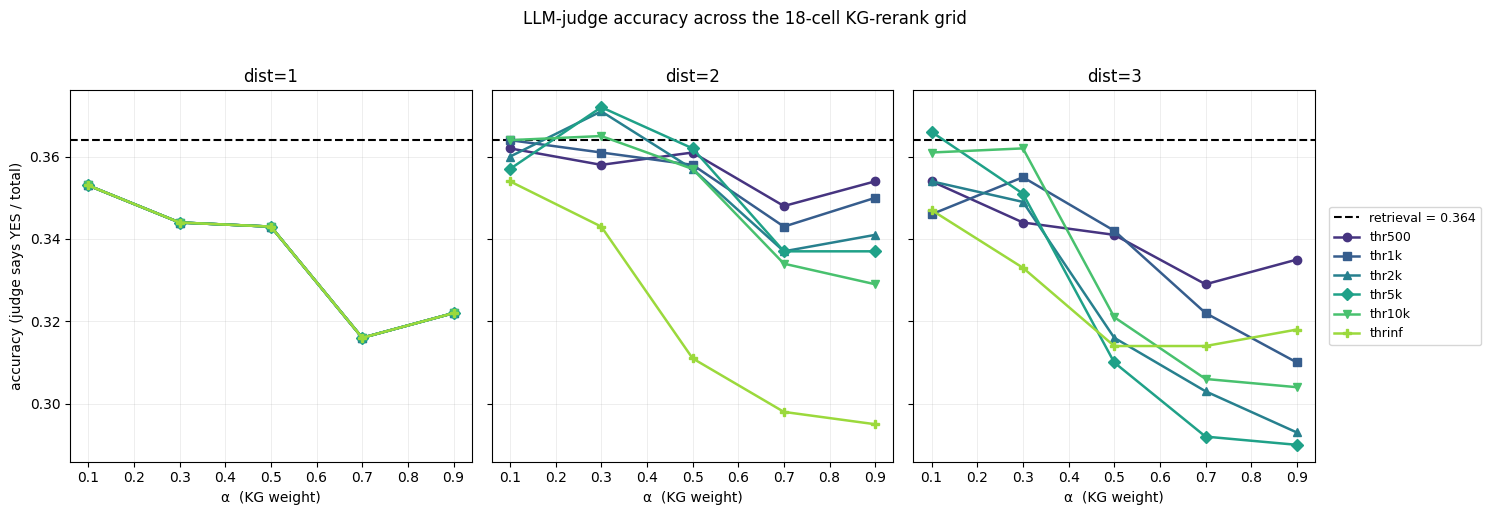

In [31]:
import matplotlib.pyplot as plt

retrieval_acc = agg.loc["retrieval", "accuracy"]
fig, axes = plt.subplots(1, len(CELL_DIST_VARIANTS), figsize=(15, 5), sharey=True)

# Markers and colors per threshold (consistent across subplots for legibility)
thr_markers = ["o", "s", "^", "D", "v", "P"]
thr_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(THR_VARIANTS)))

xs = ALPHAS_TO_TEST
for ax, dist in zip(axes, CELL_DIST_VARIANTS):
    # Retrieval baseline (same value in every subplot — α-independent)
    ax.axhline(retrieval_acc, color="black", linestyle="--", linewidth=1.5,
               label=f"retrieval = {retrieval_acc:.3f}")

    # 6 curves, one per threshold
    for (thr_value, thr_label), marker, color in zip(THR_VARIANTS, thr_markers, thr_colors):
        ys = [
            agg.loc[f"alpha_{int(round(a * 10))}_dist{dist}_{thr_label}", "accuracy"]
            for a in xs
        ]
        ax.plot(xs, ys, marker=marker, color=color, linewidth=1.8, label=thr_label)

    ax.set_title(f"dist={dist}")
    ax.set_xlabel("α  (KG weight)")
    ax.grid(True, alpha=0.3)
    if dist == CELL_DIST_VARIANTS[0]:
        ax.set_ylabel("accuracy (judge says YES / total)")

# Single legend outside the right edge — avoids cluttering each subplot
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
fig.suptitle("LLM-judge accuracy across the 18-cell KG-rerank grid", y=1.02)
plt.tight_layout()
plt.show()

## 9 · McNemar significance + sanity spot-check

### 9.1 · McNemar test — retrieval vs each rerank condition

**What it tests.** Each query is a *paired* observation (was retrieval
correct? was condition X correct?). McNemar's null hypothesis H0 is that the
two systems are **equally accurate** — i.e. their disagreement is *symmetric*.
Note: "equally accurate" is NOT "identical": two systems can disagree on
hundreds of queries and still be equivalent under McNemar if the wins cancel
out (b ≈ c).

**The 2×2 table** (rows = retrieval verdict, cols = condition verdict). Only
the off-diagonal (discordant) cells carry information:
- `b` = retrieval=T, condition=F  (retrieval wins → KG made it worse)
- `c` = retrieval=F, condition=T  (condition wins → KG made it better)
The concordant cells (both right / both wrong) are ties and are ignored.

**The test.** McNemar's EXACT test = a two-sided binomial test on the b+c
discordant pairs (`scipy.stats.binomtest`): under H0 each disagreement is a
fair coin flip, so b ~ Binomial(b+c, 0.5). Exact (no χ² approximation), so it
stays valid when b+c is small (our case: few movers).

**How to read the p-value (carefully).** p is the probability that, *IF the
two systems were equally accurate*, pure chance alone would produce an
imbalance **at least as extreme** as the one observed. It is NOT "how random
the result is", and it is NOT P(H0 true). (Why a 0.05 cutoff gives a 5%
false-positive rate: under H0 the p-value is ~Uniform(0,1), so P(p<α | H0)=α —
the per-test error rate simply IS the threshold we choose. For the *discrete*
exact test it is actually ≤ α, i.e. slightly conservative.)
- p low ⇒ such an imbalance would be too rare under H0 ⇒ we **reject**
  equal-accuracy ⇒ a **real difference** exists.
- p tells us only **whether** they differ — NOT **which** is better (read the
  sign of `delta_acc` / `b` vs `c`) and NOT **how much it matters** (effect
  size). A low p on a *negative* `delta_acc` is a certified loss, not a win.

**Multiple comparisons — the PROBLEM.** With m tests, each true-null test is a
false positive with probability α, so we expect ~α·m of them by chance
(α·m = expected COUNT, 0.05·90 ≈ 4.5 — not a probability; the exact chance of
≥1 is 1−(1−α)^m ≈ 0.99). That is why "sig@.05 (raw)" alone over-counts.

**Bonferroni — the FIX.** It does not touch McNemar; it just raises the bar to
p < α/m per test. Then the family-wide chance of *any* false positive stays
≤ α (union bound: m·(α/m)=α, no independence needed). Cost: conservative →
loses power on small real effects (fine here — we are proving a negative).

**Four layers to read the grid.** (1) McNemar p = *do they differ?*
(2) Bonferroni = *do I still trust it after m tests?* (3) sign of `delta_acc`
= *which one wins?* (here: always KG-worse). (4) the pattern across conditions
(degradation grows with α, distance, threshold→∞) = *why?* — that mechanistic
reading is a separate analysis, not an output of the test.

In [23]:
from scipy.stats import binomtest


def mcnemar_exact(verdict_a: pd.Series, verdict_b: pd.Series) -> dict:
    """Exact McNemar test via scipy's binomial test.

    McNemar's EXACT test IS a two-sided binomial test on the discordant pairs:
    under H0 (the two methods are equally good) each of the b+c disagreements
    is a fair coin flip, so b ~ Binomial(b+c, 0.5). scipy.stats.binomtest
    returns the exact p-value DIRECTLY — no χ² approximation to hand-roll, and
    valid even when b+c is small (our case: few movers).

    b = A correct AND B incorrect   (retrieval wins)
    c = A incorrect AND B correct   (the rerank condition wins)
    n_disc = b + c                  (movers: queries whose correctness flipped)
    """
    b = int(((verdict_a == True) & (verdict_b == False)).sum())
    c = int(((verdict_a == False) & (verdict_b == True)).sum())
    n_disc = b + c
    if n_disc == 0:
        # No query changed correctness between the two methods → nothing to test.
        return {"b": b, "c": c, "n_disc": 0, "p_value": 1.0}
    # Two-sided exact test: is b (out of n_disc) far from the 50% expected under H0?
    p_value = binomtest(b, n_disc, 0.5, alternative="two-sided").pvalue
    return {"b": b, "c": c, "n_disc": n_disc, "p_value": float(p_value)}


# Pivot to (query_id × condition) wide form for paired testing.
pivot_verdict = df_judge.pivot(
    index="query_id", columns="condition", values="verdict_safe"
).reindex(columns=CONDITIONS)

# Run the exact test for every rerank condition vs the retrieval baseline.
alpha_conditions = [c for c in CONDITIONS if c != "retrieval"]
mcnemar_rows = []
for cond in alpha_conditions:
    res = mcnemar_exact(pivot_verdict["retrieval"], pivot_verdict[cond])
    delta_acc = pivot_verdict[cond].mean() - pivot_verdict["retrieval"].mean()
    mcnemar_rows.append({
        "condition": cond,
        "retrieval_only (b)": res["b"],
        "condition_only (c)": res["c"],
        "n_movers (b+c)": res["n_disc"],   # how often KG changed the answer at all
        "delta_acc": delta_acc,
        "p_exact": res["p_value"],
    })

mcnemar_df = pd.DataFrame(mcnemar_rows)

# Multiple-comparison correction.
# PROBLEM: with m tests, ~alpha*m = 0.05*90 ≈ 4.5 fire as false positives by
#   pure chance (expected COUNT; the chance of >=1 is 1-0.95^90 ≈ 99%).
# FIX (Bonferroni): demand p < alpha/m per test, so the family-wide chance of
#   ANY false positive stays <= alpha (union bound). It only raises the bar —
#   McNemar is untouched. Conservative, so for a null/negative result we EXPECT
#   ~0 conditions to survive (and any that do are KG-worse, delta_acc < 0).
m = len(alpha_conditions)
bonferroni_alpha = 0.05 / m
mcnemar_df["sig@.05 (raw)"] = mcnemar_df["p_exact"] < 0.05
mcnemar_df["sig (Bonferroni)"] = mcnemar_df["p_exact"] < bonferroni_alpha

print(f"Exact McNemar (scipy binomtest): retrieval vs each of {m} rerank conditions")
print(f"Bonferroni-corrected alpha = 0.05 / {m} = {bonferroni_alpha:.5f}")
print(mcnemar_df.to_string(index=False))
print(f"\nsignificant raw @.05:         {int(mcnemar_df['sig@.05 (raw)'].sum())} / {m}")
print(f"significant after Bonferroni:  {int(mcnemar_df['sig (Bonferroni)'].sum())} / {m}")

Exact McNemar (scipy binomtest): retrieval vs each of 90 rerank conditions
Bonferroni-corrected alpha = 0.05 / 90 = 0.00056
           condition  retrieval_only (b)  condition_only (c)  n_movers (b+c)  delta_acc      p_exact  sig@.05 (raw)  sig (Bonferroni)
alpha_1_dist1_thr500                  67                  56             123     -0.011 3.672967e-01          False             False
alpha_3_dist1_thr500                 104                  84             188     -0.020 1.656612e-01          False             False
alpha_5_dist1_thr500                 111                  90             201     -0.021 1.581653e-01          False             False
alpha_7_dist1_thr500                 128                  80             208     -0.048 1.069183e-03           True             False
alpha_9_dist1_thr500                 121                  79             200     -0.042 3.634948e-03           True             False
 alpha_1_dist1_thr1k                  67                  56            

### 9.1b · Significant conditions only

Filter the McNemar table to the conditions that reject equal-accuracy, at the
two thresholds. REMINDER: "significant" means *different*, NOT *better*. In
this grid the difference is almost always in the *worse* direction — always
read `delta_acc` (negative ⇒ KG hurts). A significant row here is a certified
loss, not a win; the delta-sign breakdown below makes that explicit.

In [29]:
# Raw-significant conditions (p_exact < 0.05), NOT corrected for multiple tests.
# Sorted by p_exact (most extreme first). Expect ~m*0.05 of these to be false
# positives by chance alone.
sig_raw = (
    mcnemar_df[mcnemar_df["sig@.05 (raw)"]]
    .sort_values("p_exact")
    .reset_index(drop=True)
)
print(f"sig@.05 (raw): {len(sig_raw)} / {m} conditions")
print(f"  delta_acc < 0 (KG worse):  {int((sig_raw['delta_acc'] < 0).sum())}")
print(f"  delta_acc > 0 (KG better): {int((sig_raw['delta_acc'] > 0).sum())}")
print(sig_raw.to_string(index=False))

sig@.05 (raw): 32 / 90 conditions
  delta_acc < 0 (KG worse):  32
  delta_acc > 0 (KG better): 0
           condition  retrieval_only (b)  condition_only (c)  n_movers (b+c)  delta_acc      p_exact  sig@.05 (raw)  sig (Bonferroni)
 alpha_9_dist3_thr5k                 143                  69             212     -0.074 4.118461e-07           True              True
 alpha_7_dist3_thr5k                 144                  72             216     -0.072 1.091992e-06           True              True
 alpha_9_dist3_thr2k                 146                  75             221     -0.071 2.057046e-06           True              True
alpha_9_dist2_thrinf                 143                  74             217     -0.069 3.263676e-06           True              True
alpha_7_dist2_thrinf                 139                  73             212     -0.066 6.839581e-06           True              True
alpha_9_dist3_thr10k                 127                  67             194     -0.060 1.973541e-0

In [30]:
# Bonferroni-significant conditions (p_exact < 0.05/m): they survive the
# multiple-comparison correction. These are the only differences we'd defend —
# and in this grid they are all KG-worse (delta_acc < 0).
sig_bonf = (
    mcnemar_df[mcnemar_df["sig (Bonferroni)"]]
    .sort_values("p_exact")
    .reset_index(drop=True)
)
print(f"sig (Bonferroni, alpha={bonferroni_alpha:.5f}): {len(sig_bonf)} / {m} conditions")
print(f"  delta_acc < 0 (KG worse):  {int((sig_bonf['delta_acc'] < 0).sum())}")
print(f"  delta_acc > 0 (KG better): {int((sig_bonf['delta_acc'] > 0).sum())}")
print(sig_bonf.to_string(index=False))

sig (Bonferroni, alpha=0.00056): 13 / 90 conditions
  delta_acc < 0 (KG worse):  13
  delta_acc > 0 (KG better): 0
           condition  retrieval_only (b)  condition_only (c)  n_movers (b+c)  delta_acc      p_exact  sig@.05 (raw)  sig (Bonferroni)
 alpha_9_dist3_thr5k                 143                  69             212     -0.074 4.118461e-07           True              True
 alpha_7_dist3_thr5k                 144                  72             216     -0.072 1.091992e-06           True              True
 alpha_9_dist3_thr2k                 146                  75             221     -0.071 2.057046e-06           True              True
alpha_9_dist2_thrinf                 143                  74             217     -0.069 3.263676e-06           True              True
alpha_7_dist2_thrinf                 139                  73             212     -0.066 6.839581e-06           True              True
alpha_9_dist3_thr10k                 127                  67             194     

### 9.2 · Sanity spot-check: random TRUE + random FALSE judgments

Eyeball check that Qwen2.5 is actually doing what we think.
Print 10 random TRUE and 10 random FALSE rows with (question, gold, response,
verdict). If verdicts look wrong → judge is unreliable for our task and
we'd need to revisit the prompt or model.

In [26]:
N_SAMPLE = 10
rng = np.random.default_rng(SEED)

for verdict_label, verdict_value in [("TRUE", True), ("FALSE", False)]:
    pool = df_judge[df_judge["verdict_safe"] == verdict_value]
    if len(pool) == 0:
        print(f"\n=== {verdict_label} samples: none available ===")
        continue
    sample_idx = rng.choice(len(pool), size=min(N_SAMPLE, len(pool)), replace=False)
    sample = pool.iloc[sample_idx]
    print(f"\n{'=' * 78}")
    print(f"=== {N_SAMPLE} random {verdict_label} judgments ===")
    print(f"{'=' * 78}")
    for _, row in sample.iterrows():
        print(f"\n[{row['condition']}]  query_id={row['query_id']}")
        print(f"  question: {queries[int(row['query_id'])].get('question', '')}")
        print(f"  gold:     {row['gold_answers']}")
        print(f"  response: {row['response']!r}")
        print(f"  judge:    {row['judge_raw']!r} → {row['verdict_bool']}")


=== 10 random TRUE judgments ===

[alpha_3_dist1_thr1k]  query_id=785
  question: the failed 1961 us invasion of cuba us referred to as this
  gold:     ['Bay of Pigs Invasion']
  response: 'Bay of Pigs Invasion'
  judge:    'YES' → True

[alpha_7_dist3_thr1k]  query_id=630
  question: what was the doctor's name that created frankenstein
  gold:     ['Victor Frankenstein']
  response: 'Frankenstein'
  judge:    'YES' → True

[alpha_5_dist1_thr1k]  query_id=21
  question: what day of the year is mothers day always celebrated
  gold:     ['the second Sunday in May']
  response: '2nd Sunday in May'
  judge:    'YES' → True

[alpha_5_dist2_thrinf]  query_id=588
  question: who had the flag first texas or chile
  gold:     ['Chile']
  response: 'Chile'
  judge:    'YES' → True

[alpha_7_dist2_thr1k]  query_id=629
  question: who has the record for most jeopardy wins
  gold:     ['Kenneth Wayne Jennings III']
  response: 'Ken Jennings'
  judge:    'YES' → True

[alpha_7_dist2_thr1k]  query_

### 9.3 · Save aggregated summary

Combine 8.1 (accuracy per condition) + 9.1 (McNemar) into one parquet
for downstream use / writeup.

In [28]:
summary = agg.copy()
summary["retrieval_baseline_acc"] = retrieval_acc
summary["delta_vs_retrieval"] = summary["accuracy"] - retrieval_acc

# Attach McNemar columns where available (retrieval row stays NaN).
# New exact-test schema (see 9.1): b/c counts, mover count, exact p-value,
# and both significance flags (raw vs Bonferroni). delta_acc is omitted —
# it duplicates delta_vs_retrieval computed above.
mcnemar_idx = mcnemar_df.set_index("condition")
for col in [
    "retrieval_only (b)", "condition_only (c)", "n_movers (b+c)",
    "p_exact", "sig@.05 (raw)", "sig (Bonferroni)",
]:
    summary[col] = mcnemar_idx[col]

summary.to_parquet(JUDGMENTS_SUMMARY_PATH, compression="snappy")
print(f"saved: {JUDGMENTS_SUMMARY_PATH.relative_to(REPO_ROOT)}  "
      f"({JUDGMENTS_SUMMARY_PATH.stat().st_size / 1024:.1f} KB)")
print()
print("final summary:")
print(summary.to_string())

saved: data\NQ_answer\llm_eval\judgments_summary.parquet  (10.8 KB)

final summary:
                      n_true  n_total  accuracy  retrieval_baseline_acc  delta_vs_retrieval  retrieval_only (b)  condition_only (c)  n_movers (b+c)       p_exact sig@.05 (raw) sig (Bonferroni)
condition                                                                                                                                                                                       
retrieval                364     1000     0.364                   0.364               0.000                 NaN                 NaN             NaN           NaN           NaN              NaN
alpha_1_dist1_thr500     353     1000     0.353                   0.364              -0.011                67.0                56.0           123.0  3.672967e-01         False            False
alpha_3_dist1_thr500     344     1000     0.344                   0.364              -0.020               104.0                84.0           18